## Problem Statement:  
Your Marketing department would like to contextualize companies website to show viable products your customers might purchase based on past orders/transactions. To help with this effort, the Marketing department contacted you to build an ML model. Analyze the provided dataset and build a predictive model to predict the probability that a given customer will buy a "printer-related product." To achieve the following  
• Share your findings with the marketing team (non-technical or Business stakeholders)  
• Build a production-ready ML Model for deployment  

## Importing Required libraries:

In [3]:
# Imports :
import matplotlib
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from tqdm import tqdm#_notebook as tqdm
import yaml

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, roc_auc_score, recall_score
import pickle

from imblearn.over_sampling import RandomOverSampler, SMOTE
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

import os, sys, json

# suppress warnings :
import warnings

if not sys.warnoptions:
    warnings.simplefilter("ignore")

In [5]:
# Display 50 columns in the joined DataFrame
pd.set_option('display.max_columns', 50)

### 📌 Creating a Data Storage Directory

This code ensures that a **'bmc_data'** directory exists in the current working directory. If not, it automatically creates one.

#### 🔹 Key Functions:
- **`os.getcwd()`** → Gets the current working directory.  
- **`os.path.join()`** → Appends `'bmc_data'` to the path.  
- **`os.makedirs()`** → Creates the directory if it doesn’t exist.  

In [7]:
# Get the current working directory
current_path = os.getcwd()

# Append the desired directory name
bmc_data_path = os.path.join(current_path, 'bmc_data')

# Optionally, if you want to create the directory if it doesn't exist
if not os.path.exists(bmc_data_path):
    os.makedirs(bmc_data_path)

### 📌 Loading and Processing Product Information from JSON

This code reads **'product_info.json'** and processes it into a **Pandas DataFrame**.

#### 🔹 Key Steps:
1. **Read JSON** → Opens and loads the file with UTF-8 encoding.  
2. **Extract Schema & Data** → Retrieves column definitions and data entries.  
3. **Create DataFrame** → Converts the extracted data into a structured Pandas DataFrame.  
4. **Set Column Names** → Uses schema field names as column headers.  
5. **Preview Data** → Displays the first few rows of the DataFrame.  

In [9]:
# Read the JSON data from 'product_info.json' with explicit encoding
file_path = os.path.join('Data\product_info.json')
with open(file_path, 'r', encoding='utf-8') as file:
    json_data = json.load(file)

# Extract the fields and data from the JSON
fields = json_data['schema']['fields']
product_data = json_data['data']

# Create a DataFrame from the product_data list
df_product_info = pd.DataFrame(product_data)

# Set the column names based on the 'name' field in the schema
df_product_info.columns = [field['name'] for field in fields]

# Print the DataFrame to see the result
df_product_info.head()

,index,Product ID,Category,Sub-Category,Product Name
0,0,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase
1,1,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,..."
2,2,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...
3,3,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table
4,4,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System


### 📊 Plotting Value Counts for Product Categories

This code visualizes the distribution of **'Category'** and **'Sub-Category'** in the product dataset using bar plots.

#### 🔹 Key Steps:
1. **Plot 'Category' Distribution**  
   - Uses `countplot` to show the frequency of each **Category**.  
   - Orders bars based on count (descending).  
   - Rotates x-axis labels for better readability.  

2. **Plot 'Sub-Category' Distribution**  
   - Similar to the **Category** plot but for **Sub-Category**.  
   - Adjusts figure size and rotates labels for better visibility.  

These visualizations help understand product distribution across different categories.

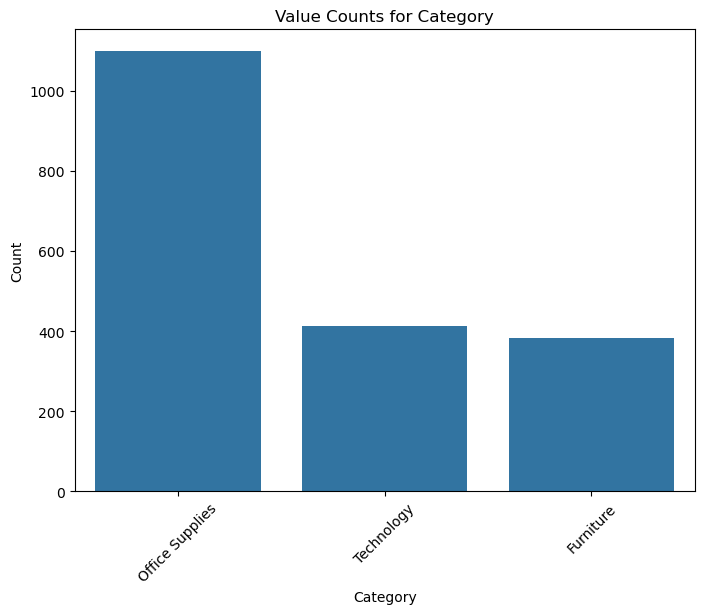

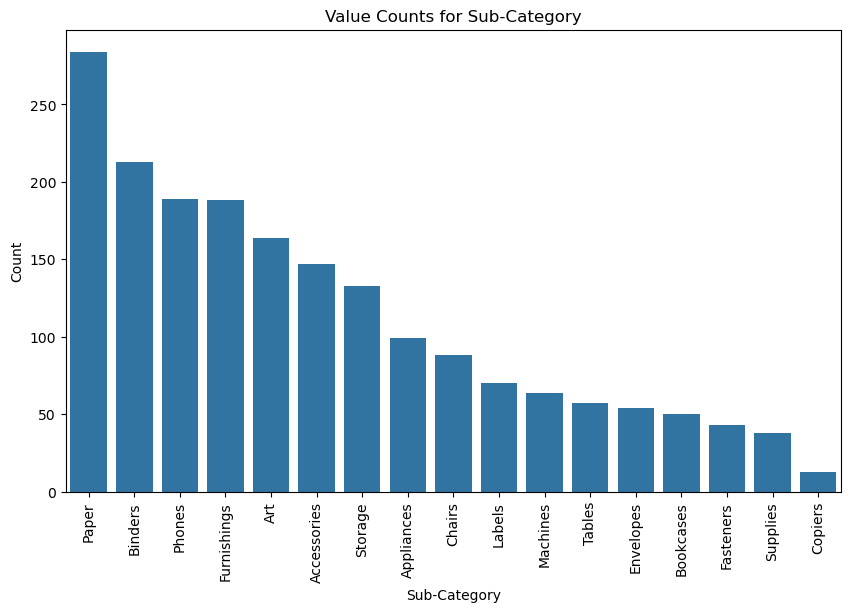

In [11]:
# Plot value counts for 'Category'
plt.figure(figsize=(8, 6))
sns.countplot(data=df_product_info, x='Category', order=df_product_info['Category'].value_counts().index)
plt.title('Value Counts for Category')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# Plot value counts for 'Sub-Category'
plt.figure(figsize=(10, 6))
sns.countplot(data=df_product_info, x='Sub-Category', order=df_product_info['Sub-Category'].value_counts().index)
plt.title('Value Counts for Sub-Category')
plt.xlabel('Sub-Category')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()

### 🖨️ Identifying Printer-Related Products

This code creates a new boolean column **'printer_related'** in the `df_product_info` DataFrame to flag products that are likely **printer-related**.

#### 🔹 Logic:
- Checks if **'Product Name'** contains the word **"printer"** (case-insensitive).  
- Ensures that the product belongs to the **'Machines'** sub-category.  
- Assigns `True` if both conditions are met, otherwise `False`.  

This helps in filtering and analyzing printer-related products efficiently.

In [13]:
df_product_info['printer_related'] = (
    (df_product_info['Product Name'].str.contains("printer", case=False))
    & (df_product_info['Sub-Category'] == "Machines")
)

### 🔍 Displaying the First Few Rows of `df_product_info`
The `.head()` function is used to display the first 5 rows of the `df_product_info` DataFrame.  
This helps in verifying the structure, column names, and initial data after processing.

In [15]:
df_product_info.head()

,index,Product ID,Category,Sub-Category,Product Name,printer_related
0,0,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,False
1,1,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",False
2,2,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,False
3,3,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,False
4,4,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,False


### 🔧 Dropping the 'index' Column  
The `drop()` function is used to remove the 'index' column from `df_product_info`.  
- `axis=1` → Specifies that we are dropping a column (not a row).  
- `inplace=True` → Modifies the DataFrame directly without returning a new one.  

In [17]:
# Assuming df_product_info is the DataFrame containing the data you provided
df_product_info.drop('index', axis=1, inplace=True)

### 📊 Plotting Value Counts for 'printer_related'
This visualization helps understand the distribution of products classified as "printer-related."

- `sns.countplot()` → Creates a bar plot for the 'printer_related' column.
- `figsize=(6, 4)` → Defines the figure size.
- `plt.title()` → Sets the plot title.
- `plt.xlabel()` & `plt.ylabel()` → Label axes for better readability.

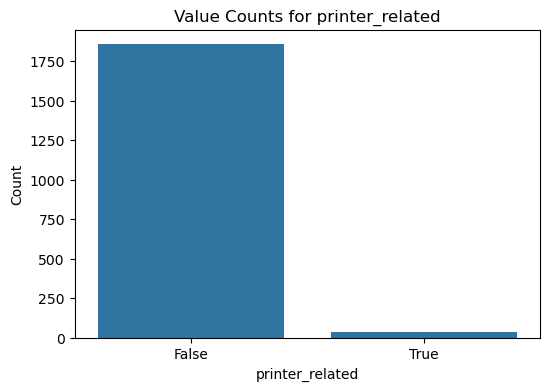

In [19]:

# Plot value counts for 'printer_related'
plt.figure(figsize=(6, 4))
sns.countplot(data=df_product_info, x='printer_related')
plt.title('Value Counts for printer_related')
plt.xlabel('printer_related')
plt.ylabel('Count')
plt.show()

### 📏 DataFrame Shape
Displays the dimensions of `df_product_info` in the format `(rows, columns)`, indicating the number of records and features in the dataset.

In [21]:
df_product_info.shape

(1894, 5)

### 🔢 Unique Value Counts
Displays the number of unique values for each column in `df_product_info`, helping to understand the dataset's variability and categorical distributions.

In [23]:
df_product_info.nunique()

Product ID         1862
Category              3
Sub-Category         17
Product Name       1850
printer_related       2
dtype: int64

### 📊 Value Counts for 'printer_related'
Displays the count of `True` and `False` values in the `printer_related` column, indicating how many products are classified as "printer-related."

In [25]:
df_product_info['printer_related'].value_counts()

printer_related
False    1856
True       38
Name: count, dtype: int64

**Only 2% products are printer related**

### 🔍 DataFrame Information
Displays a summary of the `df_product_info` DataFrame, including the number of non-null values, data types, and memory usage.

In [28]:
df_product_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1894 entries, 0 to 1893
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Product ID       1894 non-null   object
 1   Category         1894 non-null   object
 2   Sub-Category     1894 non-null   object
 3   Product Name     1894 non-null   object
 4   printer_related  1894 non-null   bool  
dtypes: bool(1), object(4)
memory usage: 61.2+ KB


### 📂 Reading JSON Data: `customer_transaction_info.json`
- Reads the `customer_transaction_info.json` file from the `Data` directory.
- Uses `utf-8` encoding to ensure proper character handling.
- Extracts the `data` and `columns` fields to create a pandas DataFrame.
- Implements error handling to catch and display any issues during file loading.
- Displays the first few rows of `df_customer_transaction_info` to verify the data.

In [30]:
# Read the JSON data from 'customer_transaction_info.json'
file_path = os.path.join( 'Data\customer_transaction_info.json')
try:
    with open(file_path, 'r', encoding='utf-8') as file:
        json_data = json.load(file)
        # Assuming each JSON file can be directly converted to a DataFrame using pandas
        df_customer_transaction_info = pd.DataFrame(json_data['data'], columns=json_data['columns'])
except Exception as e:
    print(f"Error loading JSON data from customer_transaction_info.json: {e}")
    # Handle the error or skip the file as needed

# Print the DataFrame to see the result
df_customer_transaction_info.head()

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Product ID,Sales,Quantity,Discount,Profit
0,CA-2016-152156,1478563200000,1478822400000,Second Class,CG-12520,FUR-BO-10001798,261.9600,2,0.00,41.9136
1,CA-2016-152156,1478563200000,1478822400000,Second Class,CG-12520,FUR-CH-10000454,731.9400,3,0.00,219.5820
2,CA-2016-138688,1465689600000,1466035200000,Second Class,DV-13045,OFF-LA-10000240,14.6200,2,0.00,6.8714
3,US-2015-108966,1444521600000,1445126400000,Standard Class,SO-20335,FUR-TA-10000577,957.5775,5,0.45,-383.0310
4,US-2015-108966,1444521600000,1445126400000,Standard Class,SO-20335,OFF-ST-10000760,22.3680,2,0.20,2.5164


In [32]:
df_customer_transaction_info.shape

(9994, 10)

In [34]:
df_customer_transaction_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Order ID     9994 non-null   object 
 1   Order Date   9994 non-null   int64  
 2   Ship Date    9994 non-null   int64  
 3   Ship Mode    9994 non-null   object 
 4   Customer ID  9994 non-null   object 
 5   Product ID   9994 non-null   object 
 6   Sales        9994 non-null   float64
 7   Quantity     9994 non-null   int64  
 8   Discount     9994 non-null   float64
 9   Profit       9994 non-null   float64
dtypes: float64(3), int64(3), object(4)
memory usage: 780.9+ KB


### 🕒 Converting Timestamps to Readable Date Format
- Converts `Order Date` and `Ship Date` from Unix timestamps (milliseconds) to human-readable datetime format.
- Divides timestamps by `1000` to convert from milliseconds to seconds.
- Uses `pd.to_datetime(..., unit='s')` to transform the values into proper datetime objects.

In [36]:
# Convert timestamps to readable date format
df_customer_transaction_info['Order Date'] = pd.to_datetime(df_customer_transaction_info['Order Date'] / 1000, unit='s')
df_customer_transaction_info['Ship Date'] = pd.to_datetime(df_customer_transaction_info['Ship Date'] / 1000, unit='s')

In [38]:
df_customer_transaction_info.head()

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Product ID,Sales,Quantity,Discount,Profit
0,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,FUR-BO-10001798,261.9600,2,0.00,41.9136
1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,FUR-CH-10000454,731.9400,3,0.00,219.5820
2,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,OFF-LA-10000240,14.6200,2,0.00,6.8714
3,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,FUR-TA-10000577,957.5775,5,0.45,-383.0310
4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,OFF-ST-10000760,22.3680,2,0.20,2.5164


### 📊 Feature Engineering & Time-Based Insights
- **New Features Created:**
  - `Total Revenue` = `Sales` × `Quantity`
  - `Average Profit per Unit` = `Profit` / `Quantity`
  
- **Extracted Time Features from `Order Date`:**
  - `Order Year`
  - `Order Month`
  - `Order Day`
  - `Order Day of Week`

- **Shipping Analysis:**
  - `Order to Ship Duration` (days between `Order Date` and `Ship Date`)

In [40]:
# Create new features
df_customer_transaction_info['Total Revenue'] = df_customer_transaction_info['Sales'] * df_customer_transaction_info['Quantity']
df_customer_transaction_info['Average Profit per Unit'] = df_customer_transaction_info['Profit'] / df_customer_transaction_info['Quantity']

# Extract time-related features
df_customer_transaction_info['Order Year'] = df_customer_transaction_info['Order Date'].dt.year
df_customer_transaction_info['Order Month'] = df_customer_transaction_info['Order Date'].dt.month
df_customer_transaction_info['Order Day'] = df_customer_transaction_info['Order Date'].dt.day
df_customer_transaction_info['Order Day of Week'] = df_customer_transaction_info['Order Date'].dt.dayofweek

# Calculate time duration between order and shipping
df_customer_transaction_info['Order to Ship Duration'] = (df_customer_transaction_info['Ship Date'] - df_customer_transaction_info['Order Date']).dt.days

In [42]:
df_customer_transaction_info.head()

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Product ID,Sales,Quantity,Discount,Profit,Total Revenue,Average Profit per Unit,Order Year,Order Month,Order Day,Order Day of Week,Order to Ship Duration
0,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,FUR-BO-10001798,261.9600,2,0.00,41.9136,523.9200,20.9568,2016,11,8,1,3
1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,FUR-CH-10000454,731.9400,3,0.00,219.5820,2195.8200,73.1940,2016,11,8,1,3
2,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,OFF-LA-10000240,14.6200,2,0.00,6.8714,29.2400,3.4357,2016,6,12,6,4
3,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,FUR-TA-10000577,957.5775,5,0.45,-383.0310,4787.8875,-76.6062,2015,10,11,6,7
4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,OFF-ST-10000760,22.3680,2,0.20,2.5164,44.7360,1.2582,2015,10,11,6,7


### 📂 JSON Data Extraction & Processing

#### 🔍 Function: `read_json_to_dataframe(file_name)`
- Reads a JSON file and converts it into a Pandas DataFrame.
- Supports various JSON formats:
  - List of dictionaries.
  - Dictionary with `'data'` and `'columns'` keys.
  - Dictionary with integer-based keys.

#### 📜 Function: `print_truncated_json(json_data, max_lines=20)`
- Prints a truncated version of JSON data for preview.

#### 📄 Processed Files:
1. **`customers_info.json`** → `df_customers_info`
2. **`orders_returned_info.json`** → `df_orders_returned_info`
3. **`region_seller_info.json`** → `df_region_seller_info`

#### 📊 Data Preview:
- Displays the first few rows of each DataFrame to verify the structure.

In [46]:
# Function to read JSON data from a file and return a DataFrame
def read_json_to_dataframe(file_name):
    file_path = os.path.join(file_name)
    try:
        with open(file_path, 'r', encoding='utf-8') as file:
            json_data = json.load(file)
            if isinstance(json_data, list):
                # Assuming the JSON file is a list of dictionaries
                df = pd.DataFrame(json_data)
            elif isinstance(json_data, dict) and 'data' in json_data and 'columns' in json_data:
                # Assuming the JSON file can be directly converted to a DataFrame using pandas
                df = pd.DataFrame(json_data['data'], columns=json_data['columns'])
            elif isinstance(json_data, dict) and all(key.isdigit() for key in json_data.keys()):
                # Assuming the JSON file is a dictionary with integer keys
                df = pd.DataFrame([json_data[key] for key in json_data], index=json_data.keys())
            elif isinstance(json_data, dict) and all(key.isdigit() for key in json_data.keys()):
                # Assuming the JSON file has keys representing row indices
                df = pd.DataFrame([json_data[str(key)] for key in range(len(json_data))])
            else:
                print(f"Unknown JSON format in {file_name}")
                df = None
            return df
    except Exception as e:
        print(f"Error loading JSON data from {file_name}: {e}")
        return None

# Function to print truncated JSON
def print_truncated_json(json_data, max_lines=20):
    truncated_data = json.dumps(json_data, indent=2)[:max_lines*2]
    if len(json_data) > max_lines:
        truncated_data += "\n..."
    print(truncated_data)

# Read the files and convert them to DataFrames

# Read the 'customers_info.json' file
df_customers_info = read_json_to_dataframe('Data\customers_info.json')

# Read the 'orders_returned_info.json' file
df_orders_returned_info = read_json_to_dataframe('Data\orders_returned_info.json')

# Read the 'region_seller_info.json' file
df_region_seller_info = read_json_to_dataframe('Data\region_seller_info.json')

# Print the first few rows of each DataFrame
print("DataFrame for customers_info.json:")
if df_customers_info is not None:
    print(df_customers_info.head())

print("\nDataFrame for orders_returned_info.json:")
if df_orders_returned_info is not None:
    print(df_orders_returned_info.head())

print("\nDataFrame for region_seller_info.json:")
if df_region_seller_info is not None:
    print(df_region_seller_info.head())

egion_seller_info.json: [Errno 22] Invalid argument: 'Data\region_seller_info.json'
DataFrame for customers_info.json:
  Customer ID    Customer Name    Segment        Country             City  \
0    CG-12520      Claire Gute   Consumer  United States        Henderson   
1    DV-13045  Darrin Van Huff  Corporate  United States      Los Angeles   
2    SO-20335   Sean O'Donnell   Consumer  United States  Fort Lauderdale   
3    BH-11710  Brosina Hoffman   Consumer  United States      Los Angeles   
4    AA-10480     Andrew Allen   Consumer  United States          Concord   

            State  Postal Code Region  
0        Kentucky        42420  South  
1      California        90036   West  
2         Florida        33311  South  
3      California        90032   West  
4  North Carolina        28027  South  

DataFrame for orders_returned_info.json:
  Returned        Order ID
0      Yes  CA-2017-153822
1      Yes  CA-2017-129707
2      Yes  CA-2014-152345
3      Yes  CA-2015-156440
4

## customer_info:

In [48]:
df_customers_info.head()

,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region
0,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South
1,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West
2,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South
3,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032,West
4,AA-10480,Andrew Allen,Consumer,United States,Concord,North Carolina,28027,South


In [50]:
df_customers_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4910 entries, 0 to 4909
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Customer ID    4910 non-null   object
 1   Customer Name  4910 non-null   object
 2   Segment        4910 non-null   object
 3   Country        4910 non-null   object
 4   City           4910 non-null   object
 5   State          4910 non-null   object
 6   Postal Code    4910 non-null   int64 
 7   Region         4910 non-null   object
dtypes: int64(1), object(7)
memory usage: 307.0+ KB


In [52]:
df_customers_info.nunique()

Customer ID      793
Customer Name    793
Segment            3
Country            1
City             531
State             49
Postal Code      631
Region             4
dtype: int64

In [54]:
df_customers_info.shape

(4910, 8)

### Filter DataFrame for a Specific Customer ID  
The following command filters `df_customers_info` to display only the rows where the `'Customer ID'` is `'CG-12520'`.  

```python
df_customers_info[df_customers_info['Customer ID'] == 'CG-12520']

In [56]:
df_customers_info[df_customers_info['Customer ID']=='CG-12520']

,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region
0,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South
2704,CG-12520,Claire Gute,Consumer,United States,Houston,Texas,77070,Central
3359,CG-12520,Claire Gute,Consumer,United States,Dallas,Texas,75217,Central


**The customers have multiple entry in the table**

### Bar Plot for Customer Segments  
This visualization displays the count of customers in each segment using a bar plot.

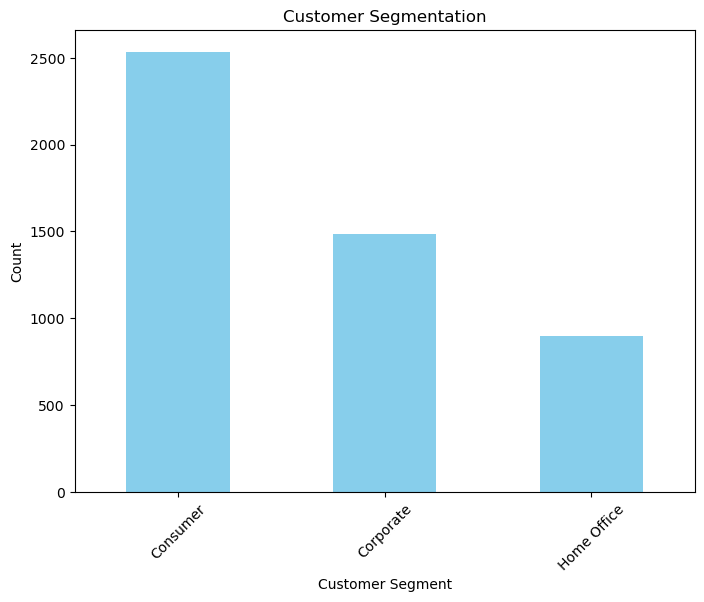

In [59]:
# Bar plot for customer segments
plt.figure(figsize=(8, 6))
df_customers_info['Segment'].value_counts().plot(kind='bar', color='skyblue')
plt.xlabel('Customer Segment')
plt.ylabel('Count')
plt.title('Customer Segmentation')
plt.xticks(rotation=45)
plt.show()


**Highest count of customers are from Consumer segments**

### Dropping the features as we want unique values of customers:

In [61]:
# Drop the specified columns from the DataFrame
df_customers_info.drop(['City', 'State', 'Postal Code', 'Region'], axis=1, inplace=True)

In [63]:
# Get unique customer data based on 'Customer ID'
df_customers_info = df_customers_info.drop_duplicates(subset='Customer ID')

In [65]:
df_customers_info.shape

(793, 4)

In [67]:
df_customers_info.head()

,Customer ID,Customer Name,Segment,Country
0,CG-12520,Claire Gute,Consumer,United States
1,DV-13045,Darrin Van Huff,Corporate,United States
2,SO-20335,Sean O'Donnell,Consumer,United States
3,BH-11710,Brosina Hoffman,Consumer,United States
4,AA-10480,Andrew Allen,Consumer,United States


In [69]:
df_orders_returned_info.head()

,Returned,Order ID
0,Yes,CA-2017-153822
1,Yes,CA-2017-129707
2,Yes,CA-2014-152345
3,Yes,CA-2015-156440
4,Yes,US-2017-155999


In [71]:
df_orders_returned_info.info()

<class 'pandas.core.frame.DataFrame'>
Index: 296 entries, 0 to 295
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Returned  296 non-null    object
 1   Order ID  296 non-null    object
dtypes: object(2)
memory usage: 6.9+ KB


### Unique Value Counts in `df_orders_returned_info`  

Displays the count of unique values for each column in the `df_orders_returned_info` DataFrame.  
This helps in understanding the variability of data in different fields.

In [73]:
df_orders_returned_info.nunique()

Returned      1
Order ID    296
dtype: int64

### Value Counts for 'Returned' Column  
This command displays the count of unique values in the 'Returned' column, showing how many orders were returned and how many were not.

In [75]:
df_orders_returned_info['Returned'].value_counts()

Returned
Yes    296
Name: count, dtype: int64

**All the orders present in this table were returned**

## df_region_seller_info:

In [77]:
df_region_seller_info

**We will not be using this dataframe as we dont have any join column**

## Data Preparation:

### Merging DataFrames  

1. **Step 1**: Merges `df_customer_transaction_info` with `df_product_info` on `"Product ID"` using a left join to bring in product details.  
2. **Step 2**: Merges the result with `df_customers_info` on `"Customer ID"` using a left join to include customer details.  

The final `merged_dataframe` contains consolidated transactional, product, and customer information.

In [79]:
# Step 1: Merge df_customer_transaction_info with df_product_info
merged_step1 = pd.merge(df_customer_transaction_info, df_product_info, on="Product ID", how="left")

# Step 2: Merge the result with df_customers_info
merged_dataframe = pd.merge(merged_step1, df_customers_info, on="Customer ID", how="left")

In [81]:
# Print the final merged DataFrame
merged_dataframe.head(2)

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Product ID,Sales,Quantity,Discount,Profit,Total Revenue,Average Profit per Unit,Order Year,Order Month,Order Day,Order Day of Week,Order to Ship Duration,Category,Sub-Category,Product Name,printer_related,Customer Name,Segment,Country
0,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,FUR-BO-10001798,261.96,2,0.0,41.9136,523.92,20.9568,2016,11,8,1,3,Furniture,Bookcases,Bush Somerset Collection Bookcase,False,Claire Gute,Consumer,United States
1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,FUR-CH-10000454,731.94,3,0.0,219.5820,2195.82,73.1940,2016,11,8,1,3,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",False,Claire Gute,Consumer,United States


In [83]:
merged_dataframe.shape

(10331, 24)

### Filtering Out Returned Orders  

1. Converts the 'Returned' column in `df_orders_returned_info` to a boolean (True for 'Yes', False otherwise).
2. Merges `df_orders_returned_info` with `merged_dataframe` to identify returned orders.
3. Filters out returned orders by keeping only non-matching rows.
4. Drops unnecessary columns ('Returned' and '_merge') after filtering.

In [85]:
# Convert 'Returned' column in df_orders_returned_info to boolean
df_orders_returned_info['Returned'] = df_orders_returned_info['Returned'] == 'Yes'

# Remove the returned orders from the main DataFrame
merged_dataframe = merged_dataframe.merge(df_orders_returned_info, how='left', on='Order ID', indicator=True)
merged_dataframe = merged_dataframe[merged_dataframe['_merge'] == 'left_only']

# Drop the 'Returned' and '_merge' columns, if needed
merged_dataframe.drop(['Returned', '_merge'], axis=1, inplace=True)

In [87]:
merged_dataframe.shape

(9500, 24)

In [89]:
merged_dataframe.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9500 entries, 0 to 10330
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Order ID                 9500 non-null   object        
 1   Order Date               9500 non-null   datetime64[ns]
 2   Ship Date                9500 non-null   datetime64[ns]
 3   Ship Mode                9500 non-null   object        
 4   Customer ID              9500 non-null   object        
 5   Product ID               9500 non-null   object        
 6   Sales                    9500 non-null   float64       
 7   Quantity                 9500 non-null   int64         
 8   Discount                 9500 non-null   float64       
 9   Profit                   9500 non-null   float64       
 10  Total Revenue            9500 non-null   float64       
 11  Average Profit per Unit  9500 non-null   float64       
 12  Order Year               9500 non-null

In [91]:
merged_dataframe.columns

Index(['Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID',
       'Product ID', 'Sales', 'Quantity', 'Discount', 'Profit',
       'Total Revenue', 'Average Profit per Unit', 'Order Year', 'Order Month',
       'Order Day', 'Order Day of Week', 'Order to Ship Duration', 'Category',
       'Sub-Category', 'Product Name', 'printer_related', 'Customer Name',
       'Segment', 'Country'],
      dtype='object')

#### **1. Data Preprocessing**
- Dropped unnecessary columns (`Order ID`, `Order Date`, `Ship Date`, `Product ID`).
- Encoded categorical columns using `LabelEncoder`.
- Separated features (`X`) and target variable (`y`).
- Split data into training and testing sets (70% train, 30% test).

#### **2. Handling Class Imbalance**
- Used `SMOTE` (Synthetic Minority Over-sampling Technique) to balance the dataset.

#### **3. Hyperparameter Tuning**
- Applied `RandomizedSearchCV` for tuning a `RandomForestClassifier` with parameters:
  - `n_estimators`: [100, 200, 300]
  - `max_depth`: [None, 5, 10, 20]
  - `min_samples_split`: [2, 5, 10]
  - `min_samples_leaf`: [1, 2, 4]
  - `max_features`: ['auto', 'sqrt', 'log2']
- Evaluated using **recall score** with 5-fold cross-validation.

#### **4. Model Training & Evaluation**
- Trained the best `RandomForestClassifier` model using optimal hyperparameters.
- Made predictions on the test set.
- Calculated:
  - **Accuracy**
  - **Recall**
  - **Classification Report**
  - **Confusion Matrix**

In [93]:
%%time 
# Drop unnecessary columns
merged_dataframe=merged_dataframe.drop(columns=['Order ID', 'Order Date', 'Ship Date', 'Product ID'])

# Encode categorical columns
encoder = LabelEncoder()
for col in merged_dataframe.select_dtypes(include='object'):
    merged_dataframe[col] = encoder.fit_transform(merged_dataframe[col])

# Separate features (X) and target (y)
X = merged_dataframe.drop('printer_related', axis=1)
y = merged_dataframe['printer_related']

# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 1: Resample the data using SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

# Step 2: Perform hyperparameter tuning using GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2']
}

rf_model = RandomForestClassifier(random_state=42)

grid_search = RandomizedSearchCV(rf_model, param_grid, scoring='recall', cv=5)
grid_search.fit(X_resampled, y_resampled)

# Best hyperparameters from grid search
best_params = grid_search.best_params_

# Train the model with best hyperparameters
best_rf_model = RandomForestClassifier(random_state=42, **best_params)
best_rf_model.fit(X_resampled, y_resampled)

# Make predictions on the test set
y_pred = best_rf_model.predict(X_test)

# Calculate accuracy and recall
accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("Best Hyperparameters:", best_params)
print("Accuracy:", accuracy)
print("Recall:", recall)

# Classification Report and Confusion Matrix
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Best Hyperparameters: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': None}
Accuracy: 0.9947368421052631
Recall: 0.7272727272727273
Classification Report:
              precision    recall  f1-score   support

       False       1.00      1.00      1.00      2828
        True       0.64      0.73      0.68        22

    accuracy                           0.99      2850
   macro avg       0.82      0.86      0.84      2850
weighted avg       1.00      0.99      0.99      2850

Confusion Matrix:
[[2819    9]
 [   6   16]]
CPU times: total: 1min 28s
Wall time: 1min 28s


### **Confusion Matrix Visualization**
- Computed the **confusion matrix** to evaluate model performance.
- Defined **labels** for better readability (`Negative Class`, `Positive Class`).
- Created a **pandas DataFrame** from the confusion matrix.
- Used **seaborn's heatmap** with the `Greens` colormap to visualize the matrix.
- Added axis labels and a title for clarity.

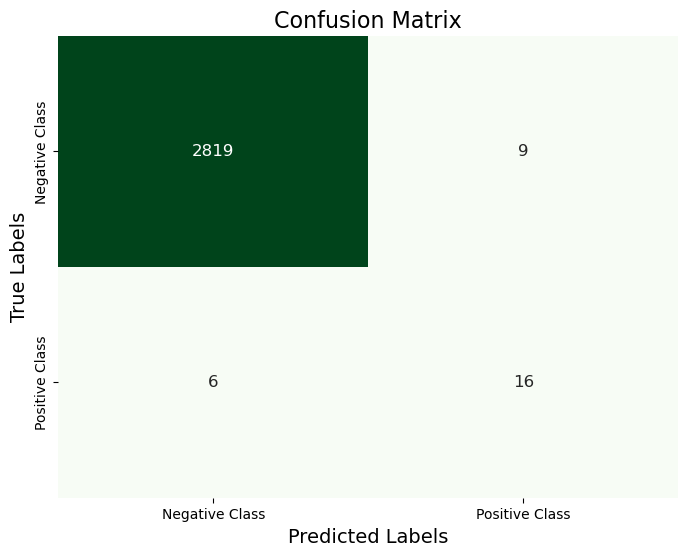

In [95]:
# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Define labels for the binary confusion matrix
labels = ['Negative Class', 'Positive Class']

# Create a DataFrame from the confusion matrix and labels
cm_df = pd.DataFrame(cm, index=labels, columns=labels)

# Plot the confusion matrix using seaborn heatmap with 'YlGnBu' color map
plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Greens', cbar=False, annot_kws={'size': 12})
plt.xlabel('Predicted Labels', fontsize=14)
plt.ylabel('True Labels', fontsize=14)
plt.title('Confusion Matrix', fontsize=16)
plt.show()

### **ROC Curve Visualization**
- Computed the **predicted probabilities** for the positive class.
- Calculated the **ROC curve** using `roc_curve()`.
- Plotted the **True Positive Rate (TPR) vs. False Positive Rate (FPR)**.
- Included the **AUC (Area Under Curve) score** in the legend.
- Added a **diagonal reference line** (random classifier) for comparison.
- Used **grid and labels** for better readability.

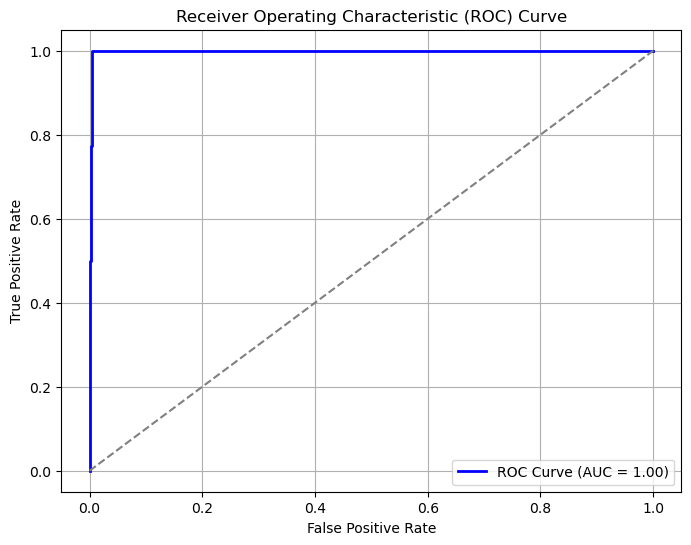

In [97]:
# Get the predicted probabilities for the positive class
y_prob = best_rf_model.predict_proba(X_test)[:, 1]

# Compute the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC Curve (AUC = {:.2f})'.format(roc_auc_score(y_test, y_prob)))
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

### **Feature Importance Plot**
- Extracted **feature importances** from the trained **Random Forest model**.
- Created a **DataFrame** with feature names and their corresponding importance scores.
- Sorted the features in **descending order** of importance.
- Plotted a **horizontal bar chart** using Seaborn (`viridis` palette) to visualize the most influential features.
- Added **labels and title** for better readability.

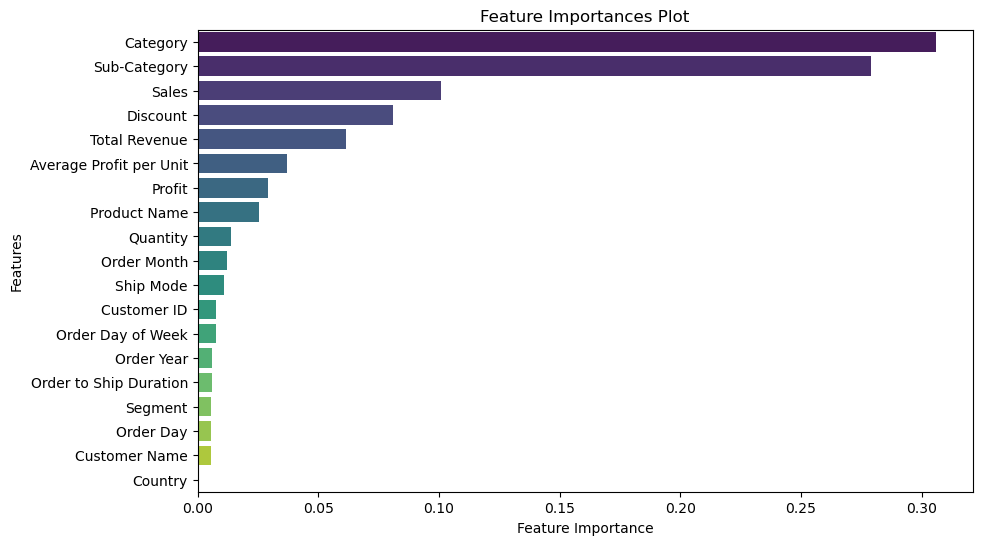

In [99]:
# Get feature importances from the trained model
importances = best_rf_model.feature_importances_

# Create a DataFrame to store feature importances
feature_importances_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})

# Sort the features by importance in descending order
feature_importances_df = feature_importances_df.sort_values(by='Importance', ascending=False)

# Plot feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importances_df, palette='viridis')
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Feature Importances Plot')
plt.show()

### **Saving the Trained Model**
- Used the **pickle** module to save the trained **Random Forest model**.
- The model was saved as **'Finalmodel.pkl'** in **binary mode ('wb')**.
- This allows for later reloading and inference without retraining.

In [101]:
# Save the trained model as a pickle file
with open('Finalmodel.pkl', 'wb') as file:
    pickle.dump(best_rf_model, file)